# Day 5 — Topic Modelling with LDA

Discovering hidden themes across 6920 movie reviews using unsupervised learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load data
df = pd.read_csv("train.tsv", delimiter='\t', header=None, names=['text', 'label'])

# Clean text (same as Day 3)
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
stop_words.update(['lrb', 'rrb', 'film', 'movie', 'one', 'make'])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)
print("Data ready:", df.shape)
print(df['clean_text'][0])

Data ready: (6920, 3)
stirring funny finally transporting imagining beauty beast horror film


In [2]:
# Vectorise using word counts (LDA needs counts, not TF-IDF)
vectorizer = CountVectorizer(max_features=2000, min_df=5, max_df=0.9)
X = vectorizer.fit_transform(df['clean_text'])

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Matrix shape:", X.shape)

# Train LDA with 8 topics
lda = LatentDirichletAllocation(
    n_components=8,
    random_state=42,
    max_iter=20,
    learning_method='batch'
)
lda.fit(X)
print("\nLDA training done!")

Vocabulary size: 2000
Matrix shape: (6920, 2000)

LDA training done!


In [3]:
def print_topics(lda, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()
    for i, topic in enumerate(lda.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:][::-1]]
        print(f"Topic {i+1}: {', '.join(top_words)}")

print_topics(lda, vectorizer)

Topic 1: like, funny, character, make, ultimately, look, big, care, self, never
Topic 2: good, nt, time, fun, would, like, movie, even, hard, way
Topic 3: nt, story, get, bad, minute, like, time, way, comedy, much
Topic 4: best, year, love, made, could, life, without, experience, woman, little
Topic 5: drama, humor, cast, long, feel, acting, good, human, eye, funny
Topic 6: like, director, time, work, well, writer, great, take, play, idea
Topic 7: comedy, may, heart, entertaining, story, tale, performance, age, make, sense
Topic 8: character, come, nt, laugh, see, old, year, performance, often, something


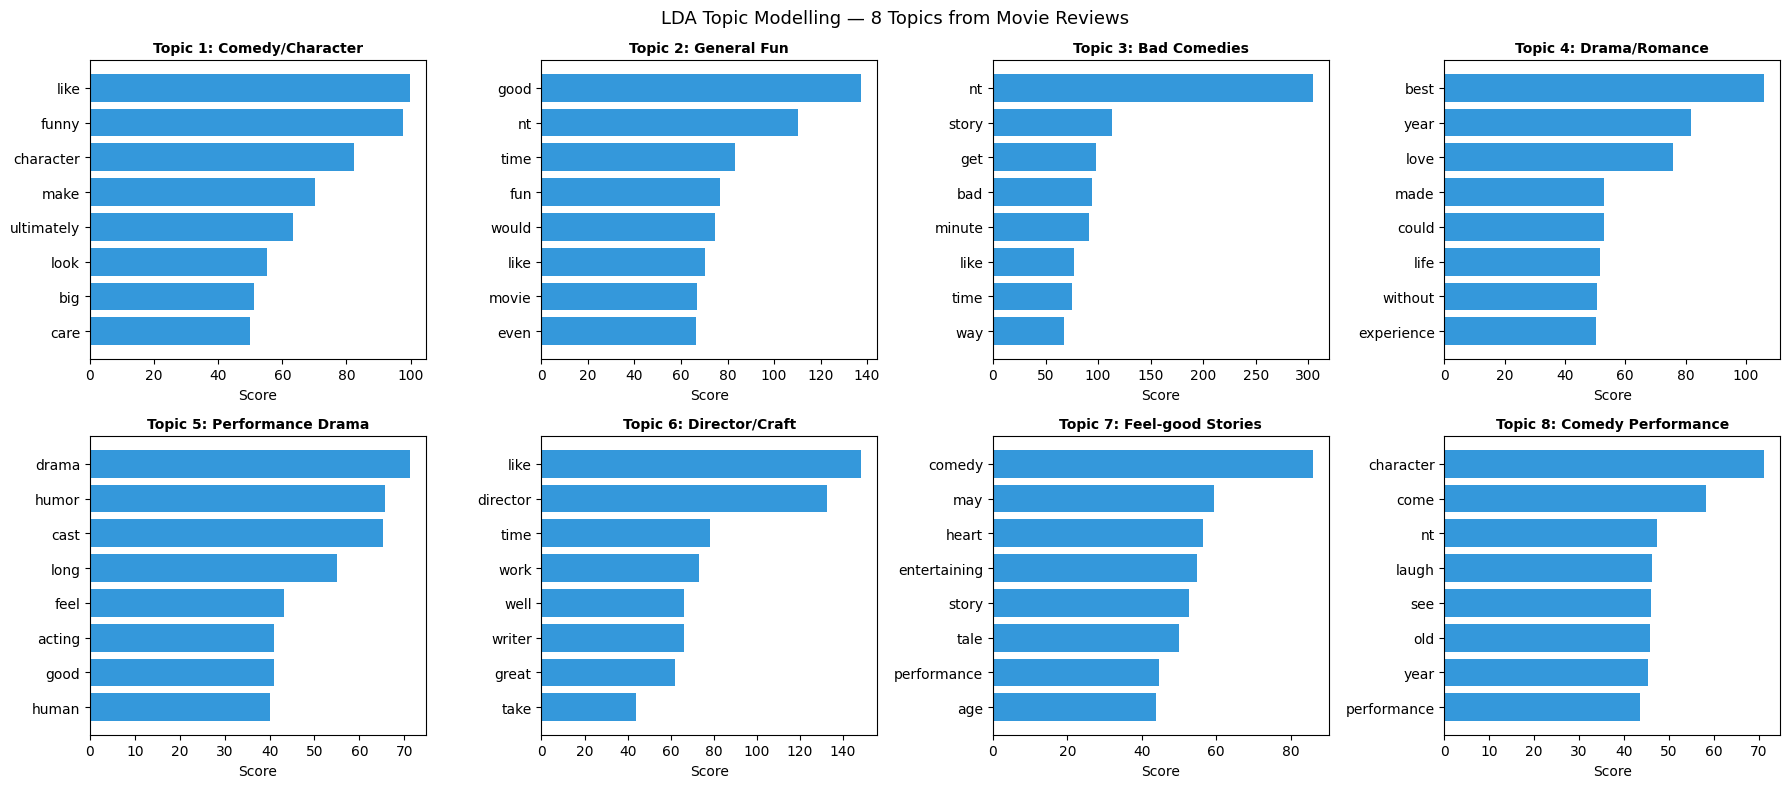

In [4]:
def plot_topics(lda, vectorizer, n_words=8):
    words = vectorizer.get_feature_names_out()
    topic_names = [
        "Comedy/Character", "General Fun", "Bad Comedies", "Drama/Romance",
        "Performance Drama", "Director/Craft", "Feel-good Stories", "Comedy Performance"
    ]
    
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    
    for i, (topic, ax) in enumerate(zip(lda.components_, axes)):
        top_idx = topic.argsort()[-n_words:][::-1]
        top_words = [words[j] for j in top_idx]
        top_scores = [topic[j] for j in top_idx]
        
        ax.barh(top_words[::-1], top_scores[::-1], color='#3498db')
        ax.set_title(f"Topic {i+1}: {topic_names[i]}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Score')
    
    plt.suptitle('LDA Topic Modelling — 8 Topics from Movie Reviews', fontsize=13)
    plt.tight_layout()
    plt.savefig('chart_topics.png', dpi=150)
    plt.show()

plot_topics(lda, vectorizer)

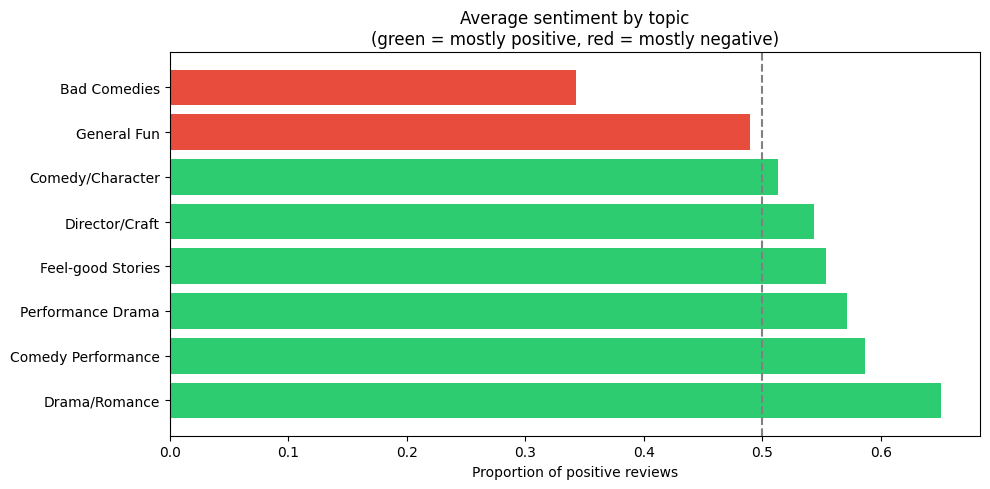


Sentiment by topic:
topic_name
Drama/Romance         0.651
Comedy Performance    0.587
Performance Drama     0.572
Feel-good Stories     0.554
Director/Craft        0.544
Comedy/Character      0.514
General Fun           0.489
Bad Comedies          0.343
Name: label, dtype: float64


In [5]:
# Get topic distribution for each review
topic_distributions = lda.transform(X)

# Add dominant topic to dataframe
df['dominant_topic'] = topic_distributions.argmax(axis=1) + 1

topic_names = {
    1: "Comedy/Character", 2: "General Fun", 3: "Bad Comedies", 4: "Drama/Romance",
    5: "Performance Drama", 6: "Director/Craft", 7: "Feel-good Stories", 8: "Comedy Performance"
}
df['topic_name'] = df['dominant_topic'].map(topic_names)

# Average sentiment per topic
topic_sentiment = df.groupby('topic_name')['label'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if x > 0.5 else '#e74c3c' for x in topic_sentiment.values]
plt.barh(topic_sentiment.index, topic_sentiment.values, color=colors)
plt.axvline(x=0.5, color='gray', linestyle='--', label='50% mark')
plt.title('Average sentiment by topic\n(green = mostly positive, red = mostly negative)')
plt.xlabel('Proportion of positive reviews')
plt.tight_layout()
plt.savefig('chart_topic_sentiment.png', dpi=150)
plt.show()

print("\nSentiment by topic:")
print(topic_sentiment.round(3))

## LDA Topic Modelling Results

**8 topics discovered from 6920 reviews — no labels used**

| Topic | Sentiment Score | Interpretation |
|-------|----------------|----------------|
| Drama/Romance | 65.1% positive | Highest rated genre |
| Bad Comedies | 34.3% positive | Lowest rated — harsh reviews |
| General Fun | 48.9% positive | Most divisive |

**Key insight:** Topic modelling reveals that genre strongly predicts sentiment.
Drama/Romance reviews are nearly twice as positive as Comedy reviews that miss the mark.